In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv(r'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [47]:
# Data preparation
num_cols = list(df.dtypes[df.dtypes != 'object'].index)
cat_cols = list(df.dtypes[df.dtypes == 'object'].index)

for col in num_cols:
    df[col] = df[col].fillna(0.0)

for col in cat_cols:
    df[col] = df[col].fillna('NA')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1462 non-null   object 
 1   industry                  1462 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1462 non-null   float64
 4   employment_status         1462 non-null   object 
 5   location                  1462 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [110]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [82]:
df_train.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [111]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [112]:
# question 1

feature_importances = {}
for feature in num_cols[:-1]:

    model = LogisticRegression(solver='liblinear',C=1.0, max_iter=1000)
    model.fit(df_train[[feature]], y_train)
    y_pred = model.predict_proba(df_val[[feature]])[:, 1]
    
    # Calculate ROC AUC
    auc_score = roc_auc_score(y_val, y_pred)
    feature_importances[feature] = auc_score

sorted_features = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

print("Feature Importance based on Individual ROC AUC:")
for feature, auc in sorted_features:
    print(f"{feature}: {auc:.4f}")

Feature Importance based on Individual ROC AUC:
number_of_courses_viewed: 0.7422
interaction_count: 0.6972
annual_income: 0.5544


In [113]:
# question 1

feature_importances = {}
for feature in num_cols[:-1]:
    auc_score = roc_auc_score(y_train, df_train[[feature]])
    feature_importances[feature] = auc_score

sorted_features = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

print("Feature Importance based on Individual ROC AUC:")
for feature, auc in sorted_features:
    print(f"{feature}: {auc:.4f}")

Feature Importance based on Individual ROC AUC:
number_of_courses_viewed: 0.7636
interaction_count: 0.7383
annual_income: 0.5520


In [135]:
def train(df_train, y_train, C=1.0):

    numerical = list(df_train.dtypes[df_train.dtypes != 'object'].index)
    categorical = list(df_train.dtypes[df_train.dtypes == 'object'].index)
    
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear',C=C, max_iter=1000)
    
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df, dv, model):

    numerical = list(df.dtypes[df.dtypes != 'object'].index)
    categorical = list(df.dtypes[df.dtypes == 'object'].index)

    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [115]:
num_cols = list(df_train.dtypes[df.dtypes != 'object'].index)
cat_cols = list(df_train.dtypes[df.dtypes == 'object'].index)

In [116]:
print(df_train.columns)
print(num_cols)

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score'],
      dtype='object')
['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']


In [108]:
from sklearn.metrics import roc_auc_score, auc
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

# roc_auc_score(y_val, y_pred)

In [27]:
# y_val = num_cols[0]
# df_aux_train = df_train.drop(y_val)


In [117]:
# question 2

dv, model = train(df_train, y_train, C=1.0)

y_pred = predict(df_val, dv, model)


print(round(roc_auc_score(y_val, y_pred),3))

# y_pred2 = (y_pred >= 0.5).astype('int')
# print(round(roc_auc_score(y_val, y_pred2),3))

0.817


In [118]:
print(round(roc_auc_score(y_val, y_pred),3)-.72)
print(round(roc_auc_score(y_val, y_pred),3)-.92)

0.09699999999999998
-0.10300000000000009


In [89]:
categorical = list(df_train.dtypes[df_train.dtypes == 'object'].index)
    
dicts = df_train[categorical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dicts)

model = LogisticRegression(solver='liblinear',C=1.0, max_iter=1000)
    
model.fit(X_train, y_train)
    

dicts = df_val[categorical].to_dict(orient='records')
X = dv.transform(dicts)
y_pred = model.predict_proba(X)[:, 1]

round(roc_auc_score(y_val, y_pred),3)

0.619

In [119]:
# question 3

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

p = tp / (tp + fp)
r = tp / (tp + fn)

print("precision: ", p)
print("recall: ", r)


precision:  0.6693877551020408
recall:  0.9590643274853801


In [120]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    p = tp / (tp + fp)
    r = tp / (tp + fn)
    
    f1 = 2*((p*r)/(p+r))
    scores.append((t, tp, fp, fn, tn, p, r, f1))

columns = ['threshold', 'tp', 'fp', 'fn', 'tn', 'p', 'r', 'f1']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)


/tmp/ipykernel_2196/2835967020.py:18: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


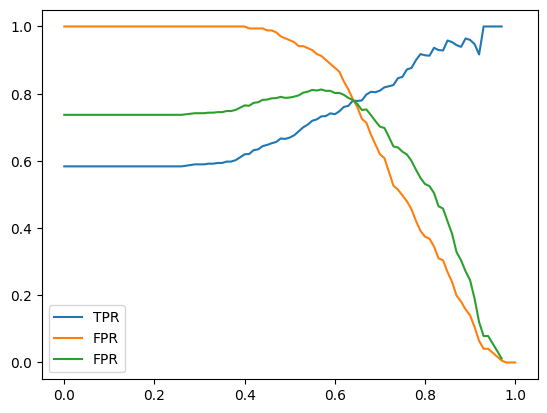

In [121]:
plt.plot(df_scores.threshold, df_scores['p'], label='TPR')
plt.plot(df_scores.threshold, df_scores['r'], label='FPR')
plt.plot(df_scores.threshold, df_scores['f1'], label='FPR')
plt.legend()

In [122]:
# df_scores.columns
df_scores[df_scores.f1 == max(df_scores.f1)]

,threshold,tp,fp,fn,tn,p,r,f1,tpr,fpr
57,0.57,156,57,15,65,0.732394,0.912281,0.8125,0.912281,0.467213


In [127]:
df_scores[df_scores['threshold'] >= 0.6][['threshold','p','r']]

,threshold,p,r
60,0.60,0.738916,0.877193
61,0.61,0.747475,0.865497
62,0.62,0.760638,0.836257
63,0.63,0.763736,0.812865
64,0.64,0.779070,0.783626
65,0.65,0.778443,0.760234
66,0.66,0.779874,0.725146
67,0.67,0.797386,0.713450
68,0.68,0.805556,0.678363
69,0.69,0.804348,0.649123


In [128]:
!pip install tqdm


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [129]:
from sklearn.model_selection import KFold

In [130]:
from tqdm.auto import tqdm

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [132]:
df_full_train.columns


Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [138]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = df_train.converted.values
    y_val = df_val.converted.values

    del df_train['converted']
    del df_val['converted']

    dv, model = train(df_train, y_train, C=1.0)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.822 +- 0.036


In [ ]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        
        y_train = df_train.converted.values
        y_val = df_val.converted.values

        del df_train['converted']
        del df_val['converted']

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

100%|██████████| 3/3 [00:00<00:00, 10.73it/s]

C=1e-06 0.822 +- 0.036
C=0.001 0.822 +- 0.036
C=1 0.822 +- 0.036
